In [ ]:
!pip install qiskit qiskit_aer --quiet
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit.circuit import Gate
from qiskit_aer import AerSimulator

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 57.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 71.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 71.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 5.0 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
%cd /content/drive/MyDrive/Colab Notebooks

[Errno 2] No such file or directory: '/content/drive/MyDrive/Colab Notebooks'
/content


In [ ]:
%run MvNM_base.ipynb

Exception: File `'MvNM_base.ipynb.py'` not found.

In [ ]:
# ========================================
# TEST CONFIGURATIONS
# ========================================
# Define which (BH_size, ENV_size, W_positions) to test

test_configs = [
    # Format: (N_BH, N_ENV, [list of W positions in ENV])

    #(8, 2, [0, 1]),              # Small ENV
    #(8, 4, [0, 1, 2, 3]),        # Medium ENV - your main case
    #(8, 6, [0, 2, 4, 5]),        # Larger ENV
    #(6, 4, [0, 1, 2, 3]),        # Smaller BH
    #(9, 4, [0, 1, 2, 3]),        # Larger BH


    (10, 4, [0, 1, 2, 3]),  # Ratio = 0.40
    (9, 4, [0, 1, 2, 3]),   # Ratio = 0.44
    (10, 5, [0, 2, 4]),     # Ratio = 0.50
]

# Measurement parameters
MAX_STEPS = 10
SHOTS = 2048
V_QUBIT = 0  # V always at qubit 0 (deep in BH)

print(f'Test configurations defined: {len(test_configs)} configurations')
total_tests = sum(len(w_list) for _, _, w_list in test_configs)
print(f'Total individual tests: {total_tests}')

Test configurations defined: 3 configurations
Total individual tests: 11


In [ ]:
# ========================================
# RUN ALL TESTS
# ========================================

all_results = []
test_num = 0
total_tests = sum(len(w_list) for _, _, w_list in test_configs)

print('='*70)
print('Starting automated OTOC measurements')
print('='*70)

for N_BH, N_ENV, w_positions in test_configs:

    # Update the global variables that your base file uses
    TOTAL_QUBITS = N_BH + N_ENV

    print(f'\nConfiguration: BH={N_BH}, ENV={N_ENV}')
    print(f'  Total qubits: {TOTAL_QUBITS}')
    print(f'  Testing W positions: {w_positions}')
    print('-'*70)

    for w_offset in w_positions:
        test_num += 1
        w_index = N_BH + w_offset  # W qubit absolute position

        print(f'\n[Test {test_num}/{total_tests}] BH={N_BH}, ENV={N_ENV}, W=[{w_offset}] (qubit {w_index})')

        # ===== YOUR EXISTING OTOC CODE STARTS HERE =====

        ancilla_qubit_index = TOTAL_QUBITS
        otoc_total_qubits = TOTAL_QUBITS + 1

        # Build frozen dynamics gate
        step_qc = QuantumCircuit(TOTAL_QUBITS, name="U_NvNM_step")
        bh_qubits = list(range(N_BH))
        env_qubits = list(range(N_BH, TOTAL_QUBITS))

        scramble_black_hole(step_qc, bh_qubits)
        evolve_environment(step_qc, env_qubits)
        bh_environment_interaction(step_qc, bh_qubits, env_qubits)

        U_step_gate = step_qc.to_gate()
        U_step_dag_gate = U_step_gate.inverse()

        simulator = AerSimulator()
        time_steps = list(range(MAX_STEPS + 1))
        otoc_values = []

        # Measure OTOC at each time step
        for step in time_steps:
            qc = QuantumCircuit(otoc_total_qubits, 1)
            qc.h(ancilla_qubit_index)
            sys_qubits = list(range(TOTAL_QUBITS))

            # OTOC sequence
            qc.cz(ancilla_qubit_index, V_QUBIT)

            for _ in range(step):
                qc.append(U_step_gate, sys_qubits)

            qc.x(w_index)

            for _ in range(step):
                qc.append(U_step_dag_gate, sys_qubits)

            qc.cz(ancilla_qubit_index, V_QUBIT)

            for _ in range(step):
                qc.append(U_step_gate, sys_qubits)

            qc.x(w_index)

            for _ in range(step):
                qc.append(U_step_dag_gate, sys_qubits)

            # Measure
            qc.h(ancilla_qubit_index)
            qc.measure(ancilla_qubit_index, 0)

            # Run
            qc_flat = qc.decompose()
            qc_transpiled = transpile(qc_flat, simulator)
            result = simulator.run(qc_transpiled, shots=SHOTS).result()
            counts = result.get_counts()

            p_0 = counts.get('0', 0) / SHOTS
            otoc_real = 2 * p_0 - 1
            otoc_values.append(otoc_real)

        # ===== YOUR EXISTING OTOC CODE ENDS HERE =====

        # Store results with metadata
        result_dict = {
            'n_bh': N_BH,
            'n_env': N_ENV,
            'w_position': w_offset,
            'w_qubit': w_index,
            'time_steps': time_steps,
            'otoc_values': otoc_values
        }
        all_results.append(result_dict)

        print(f'  Completed: OTOC min={min(otoc_values):.3f}, max={max(otoc_values):.3f}')

print('\n' + '='*70)
print(f'All tests complete! Total results: {len(all_results)}')
print('='*70)

Starting automated OTOC measurements

Configuration: BH=10, ENV=4
  Total qubits: 14
  Testing W positions: [0, 1, 2, 3]
----------------------------------------------------------------------

[Test 1/11] BH=10, ENV=4, W=[0] (qubit 10)
  Completed: OTOC min=-0.036, max=1.000

[Test 2/11] BH=10, ENV=4, W=[1] (qubit 11)
  Completed: OTOC min=-0.026, max=1.000

[Test 3/11] BH=10, ENV=4, W=[2] (qubit 12)
  Completed: OTOC min=-0.037, max=1.000

[Test 4/11] BH=10, ENV=4, W=[3] (qubit 13)
  Completed: OTOC min=-0.021, max=1.000

Configuration: BH=9, ENV=4
  Total qubits: 13
  Testing W positions: [0, 1, 2, 3]
----------------------------------------------------------------------

[Test 5/11] BH=9, ENV=4, W=[0] (qubit 9)
  Completed: OTOC min=-0.027, max=1.000

[Test 6/11] BH=9, ENV=4, W=[1] (qubit 10)
  Completed: OTOC min=-0.013, max=1.000

[Test 7/11] BH=9, ENV=4, W=[2] (qubit 11)
  Completed: OTOC min=-0.043, max=1.000

[Test 8/11] BH=9, ENV=4, W=[3] (qubit 12)
  Completed: OTOC min=-0.02

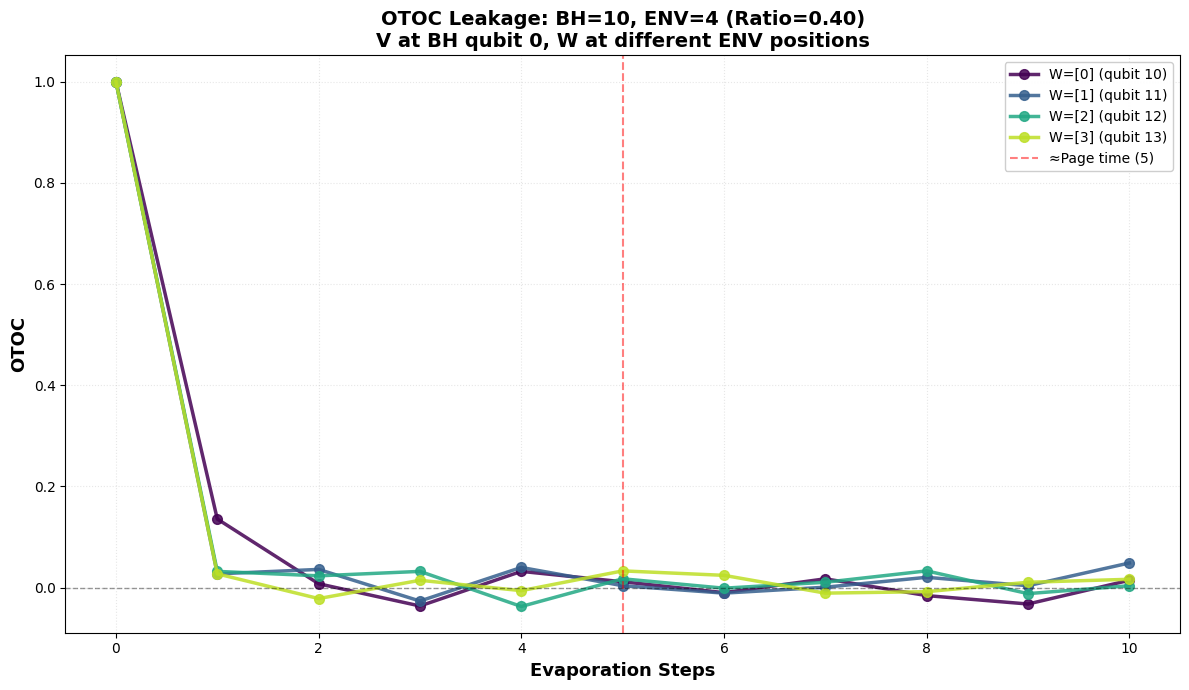

Saved: OTOC_BH10_ENV4.png


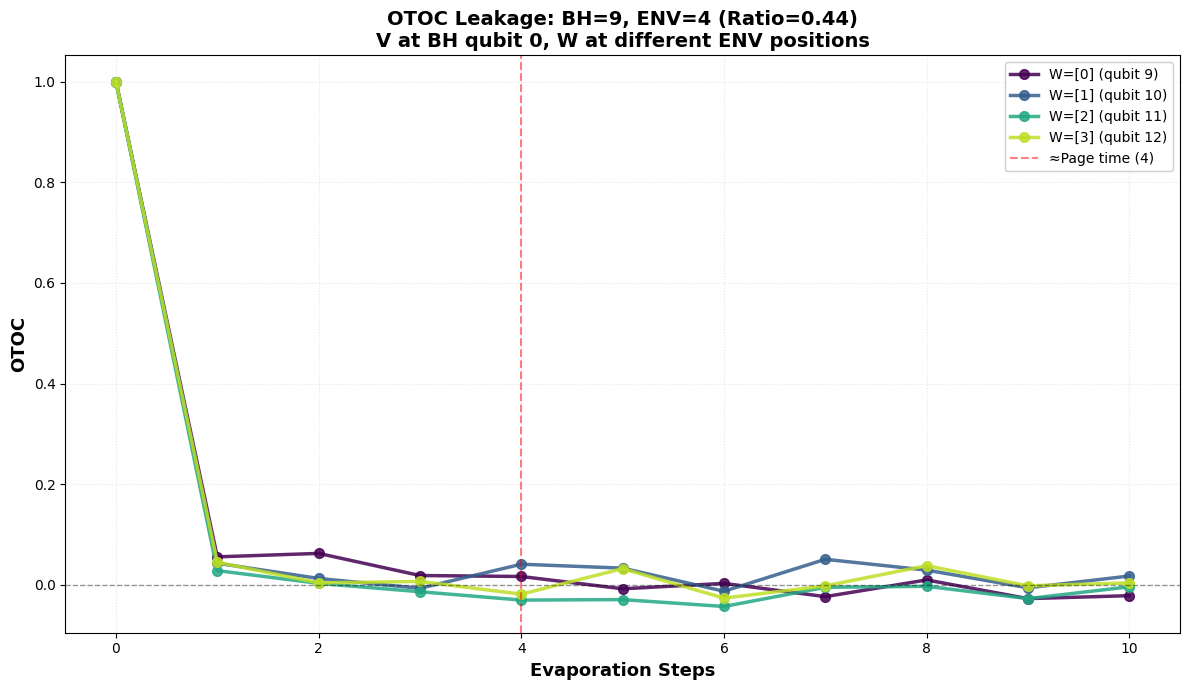

Saved: OTOC_BH9_ENV4.png


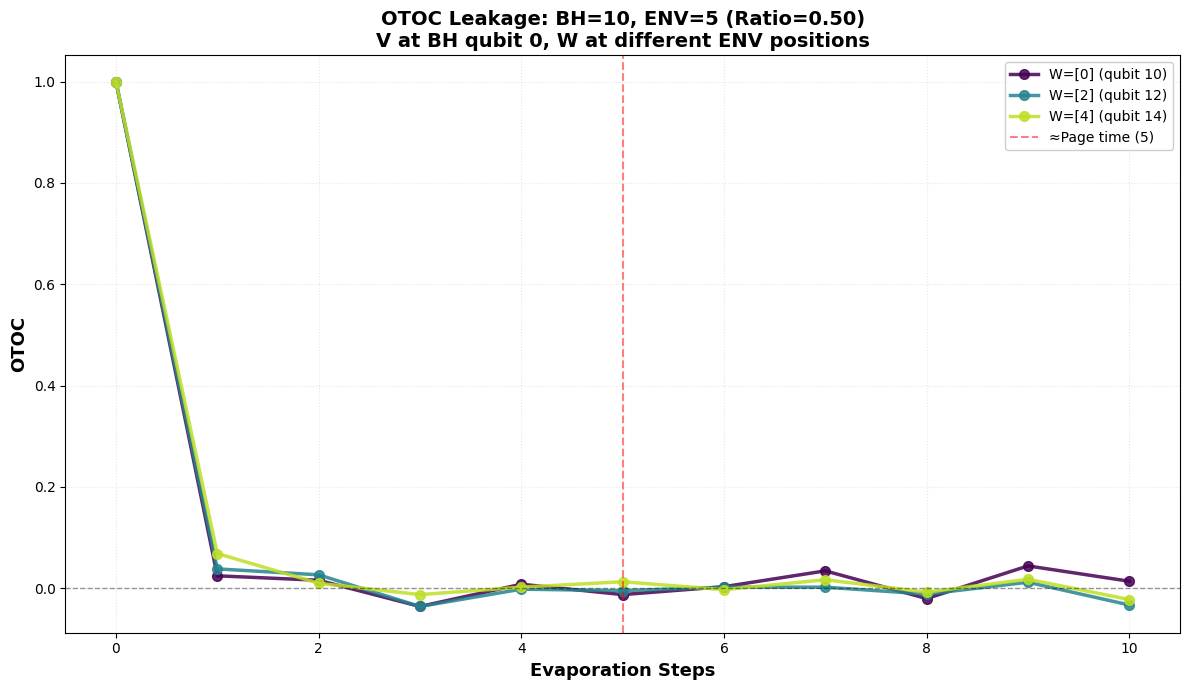

Saved: OTOC_BH10_ENV5.png

All plots generated!


In [ ]:
# ========================================
# PLOT RESULTS WITH PROPER LABELS
# ========================================

import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Group by (BH, ENV) configuration
configs = {}
for result in all_results:
    key = (result['n_bh'], result['n_env'])
    if key not in configs:
        configs[key] = []
    configs[key].append(result)

# Create one plot per (BH, ENV) configuration
for (n_bh, n_env), results in configs.items():

    fig, ax = plt.subplots(figsize=(12, 7))

    # Different color for each W position
    colors = cm.viridis(np.linspace(0, 0.9, len(results)))

    for i, result in enumerate(results):
        w_pos = result['w_position']
        w_qubit = result['w_qubit']

        # Label includes both relative and absolute position
        label = f'W=[{w_pos}] (qubit {w_qubit})'

        ax.plot(result['time_steps'], result['otoc_values'],
                marker='o', linestyle='-', linewidth=2.5,
                markersize=7, color=colors[i], label=label,
                alpha=0.85)

    # Formatting
    ax.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.4)

    # Page time marker
    page_time = n_bh // 2
    ax.axvline(page_time, color='red', linestyle='--',
              linewidth=1.5, alpha=0.5, label=f'≈Page time ({page_time})')

    ax.set_xlabel('Evaporation Steps', fontsize=13, fontweight='bold')
    ax.set_ylabel('OTOC', fontsize=13, fontweight='bold')

    ratio = n_env / n_bh
    title = (f'OTOC Leakage: BH={n_bh}, ENV={n_env} (Ratio={ratio:.2f})\n'
             f'V at BH qubit 0, W at different ENV positions')
    ax.set_title(title, fontsize=14, fontweight='bold')

    ax.legend(loc='best', fontsize=10, framealpha=0.95)
    ax.grid(True, alpha=0.3, linestyle=':')

    plt.tight_layout()
    plt.savefig(f'OTOC_BH{n_bh}_ENV{n_env}.png', dpi=300, bbox_inches='tight')
    plt.show()

    print(f'Saved: OTOC_BH{n_bh}_ENV{n_env}.png')

print('\nAll plots generated!')

In [ ]:
# ========================================
# SAVE RESULTS TO CSV
# ========================================

import pandas as pd
from datetime import datetime

# Create detailed dataset (all OTOC values)
detailed_data = []
for result in all_results:
    for step, otoc in zip(result['time_steps'], result['otoc_values']):
        detailed_data.append({
            'BH_size': result['n_bh'],
            'ENV_size': result['n_env'],
            'W_position': result['w_position'],
            'W_qubit': result['w_qubit'],
            'step': step,
            'OTOC': otoc
        })

df_detailed = pd.DataFrame(detailed_data)

# Save with timestamp
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
filename = f'otoc_results_{timestamp}.csv'
df_detailed.to_csv(filename, index=False)

print(f'Results saved to: {filename}')
print(f'Total rows: {len(df_detailed)}')
print('\nPreview:')
print(df_detailed.head(20))

Results saved to: otoc_results_20260214_112925.csv
Total rows: 198

Preview:
    BH_size  ENV_size  W_position  W_qubit  step      OTOC
0         8         2           0        8     0  1.000000
1         8         2           0        8     1  0.055664
2         8         2           0        8     2  0.012695
3         8         2           0        8     3  0.050781
4         8         2           0        8     4 -0.004883
5         8         2           0        8     5  0.044922
6         8         2           0        8     6  0.025391
7         8         2           0        8     7 -0.049805
8         8         2           0        8     8  0.005859
9         8         2           0        8     9 -0.001953
10        8         2           0        8    10 -0.061523
11        8         2           1        9     0  1.000000
12        8         2           1        9     1  0.092773
13        8         2           1        9     2  0.046875
14        8         2           1     